Name Taherunnesa Rahi

Labpartner(s)

In [1]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

**For today's lab you need to install the package cartopy**

In [ ]:
# you can install packages here in a notebook with pip or conda, 
# or in the anaconda navigator in the environments tab (reccommended)
# pip install cartopy
# conda install cartopy

In [ ]:
# I had an old version of cartopy so I had to upgrade:
# pip install --upgrade cartopy

In [2]:
import cartopy.crs as ccrs   #import map styles/types
import cartopy.feature as cfeature  # features such as the ocean, coastlines rivers, etc

# Class 6.2

Today we will finish fiunction sharing and do more plotting

# Warmups 6.2

**W.1** Write some code that generates 15 random integers from 1-100. If the integers are divisible by 2 assign them to list "x" if they are divisible by three, assign them to list "y", if they are neither assign them to list "z". 

In [5]:
import random


numbers = random.sample(range(1, 101),15)

x = []  
y = []  
z = [] 

for num in numbers:
    if num % 2 == 0:
        x.append(num)
    elif num % 3 == 0:
        y.append(num)
    else:
        z.append(num)

print(x)
print(y)
print(z)


[76, 16, 92, 96, 58, 12, 46, 42, 64]
[63]
[17, 25, 59, 11, 61]


# Lecture 6.2

### Agenda:

- Show us your functions
- Questions
- xarray package and plotting netcdf files


### Show us your functions (from Lab 5.2) - continued

### Questions

### Cartopy

Let's take the data we used last time and make the plot publication ready

There are a number of differnt map projections available in Cartopy.  
https://cartopy.readthedocs.io/stable/reference/projections.html
Robinson is often used for global maps

C:\Users\Taherunnesa Rahi\anaconda3\Lib\site-packages\cartopy\io\__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


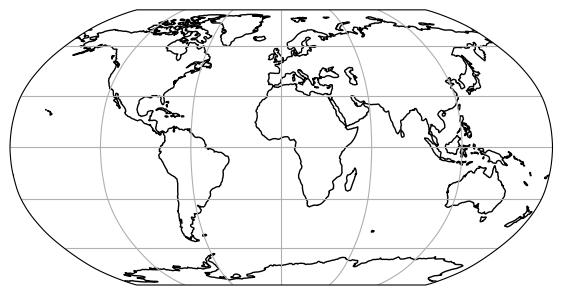

In [7]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(resolution='110m')
ax.gridlines()

When we are plotting ocean data, we like to make the Pacific contiguous, let's rotate

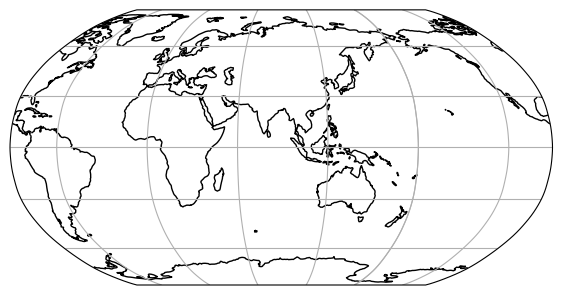

In [8]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = 89)) # this rotates the map to 203 degrees East
ax.coastlines(resolution='110m')
ax.gridlines()

Or we can rotate it so that it cuts through Indonesia (not good for mangrove or coral work)

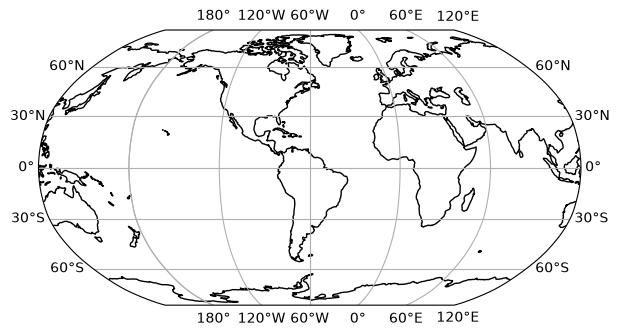

In [9]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = -60))
# -60 (60 W) is the same as 300 E (360 degrees in total 360-60W = 300E)
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True) # let's add some labels



Let's try some different map projections

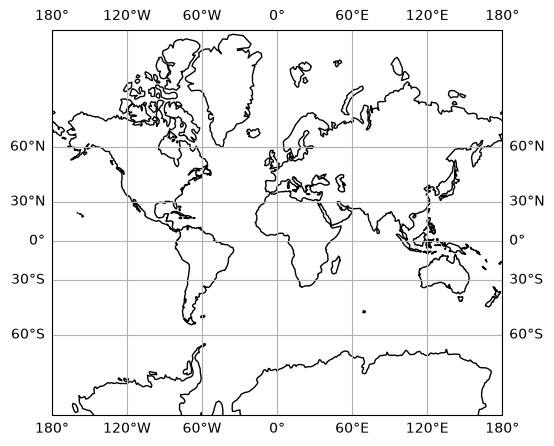

In [10]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Mercator()) # different map projection
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

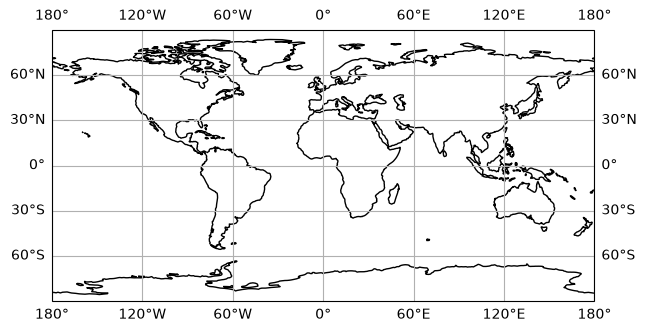

In [11]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)


How do I zoom in?

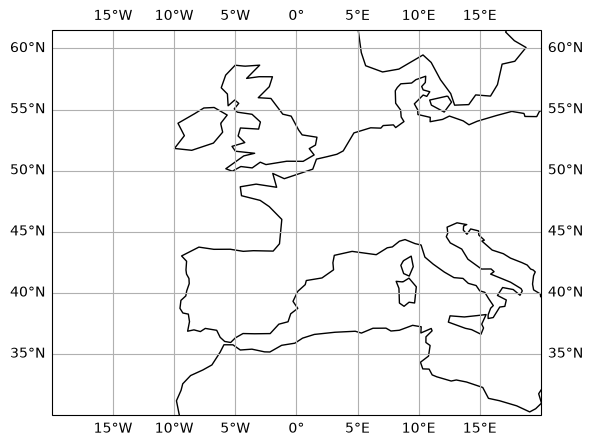

In [3]:
# let's zoom in to S Asia
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20,20,30,60]) # set the limits of the plot
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)


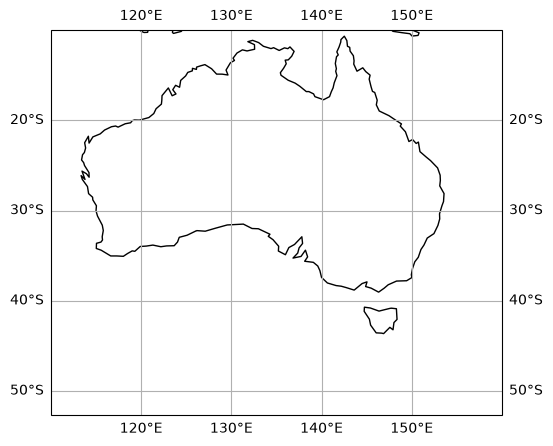

In [19]:
# make a plot of Australia

plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110,160,-10,-50]) # set the limits of the plot
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)



#### Moving back to the Gulf of Mexico, we want to set the lat and lon range to match our HYCOM data. How do we find this?

In [22]:
#insert path or url to file here
# download from the internet:
link = "https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc"

In [23]:
gom_data = xr.open_dataset(link, decode_times=False)

OSError: [Errno -68] NetCDF: I/O failure: 'https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc'

In [4]:
gom_data= xr.open_dataset(
    "039_archv.2026_001_00_2d.nc",
    decode_times=False
)

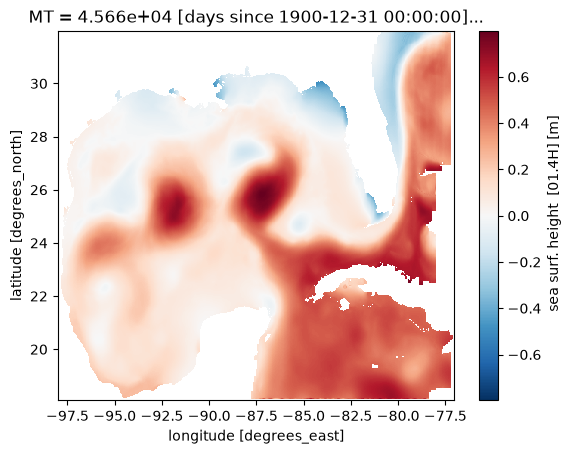

In [7]:
# let's remember what our data looked like, pick a variable to plot

gom_data.ssh.plot()

I'm going to get the max and min of the lat and lon to help me plot the data

In [6]:
lat_min = gom_data.Latitude.min()
print(lat_min)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(18.091648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [7]:
lat_max = gom_data.Latitude.max()
print(lat_max)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(31.960648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [8]:
lon_min = gom_data.Longitude.min()
print(lon_min)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-98., dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


In [9]:
lon_max = gom_data.Longitude.max()
print(lon_max)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-77.03998, dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


Now I can use them below

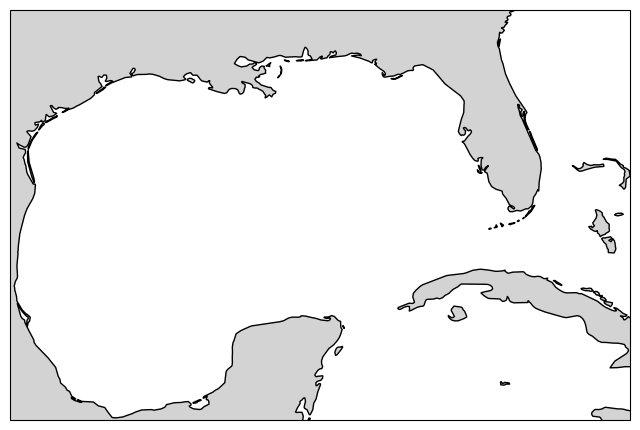

In [12]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='lightgrey')
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Let's make the land color a bit lighter gray

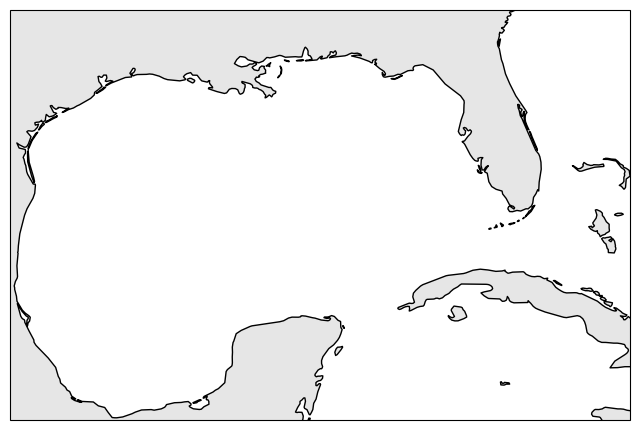

In [33]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9') # 0 is black and 1 is white
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Now let's add some data

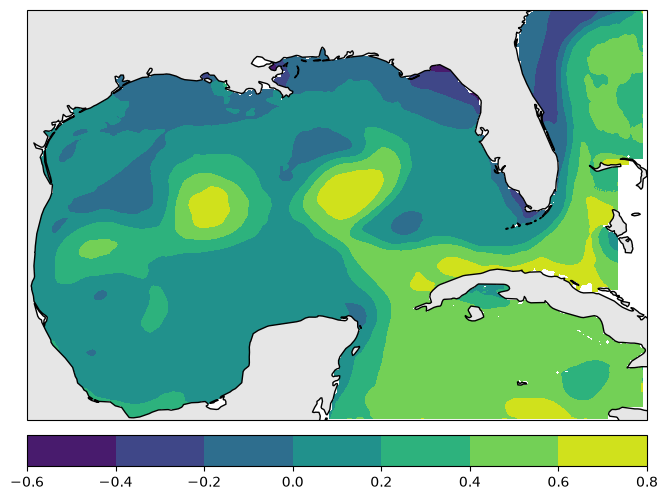

In [11]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# Contours the data on tho the map projection
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree()) # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Try taking out the options for the colorbar, what happens? What does "pad" do?

Pad adjustw the space between the plot and colorbar.


#### What is the range of our data?

In [36]:
print(var.max())

<xarray.DataArray 'ssh' ()> Size: 4B
array(0.7986358, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]


In [37]:
print(var.min())

<xarray.DataArray 'ssh' ()> Size: 4B
array(-0.504511, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]


#### Let's set the countour levels to match our data range. I'm also going to change the colormap
See https://matplotlib.org/stable/users/explain/colors/colormaps.html
Note you can reverse any colormap by appending '_r' to the name

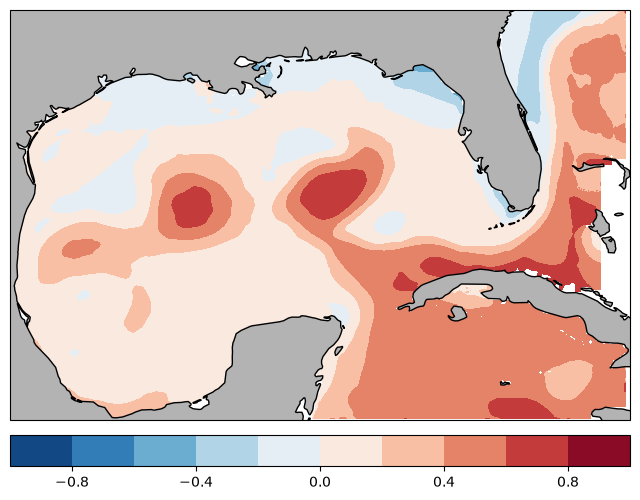

In [14]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1,1.1, 0.2) #start,stop,step  
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


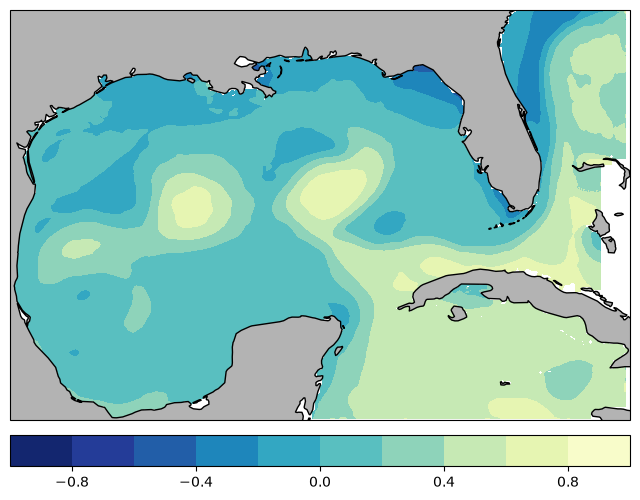

In [15]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1,1.1, 0.2) #start,stop,step  
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'YlGnBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)

#### Okay, now let's add some labels

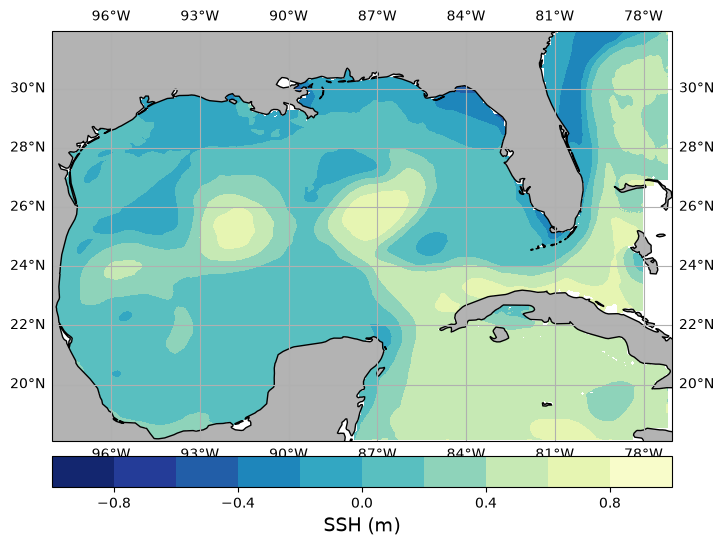

In [16]:
# copy in previous code here
# I'm also going to cut out the white bits at right by adjusting lon_max
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1,1.1, 0.2) #start,stop,step  
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'YlGnBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)

cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)


#### These labels are too small for what I want. I need them to be much bigger.

In [17]:
#Note we can easily make the lat/lon and colorbar font size bigger by adjusting the matplotlib parameters, 
# which I introduced last time
import matplotlib as mpl
mpl.rcParams['font.size'] = 14

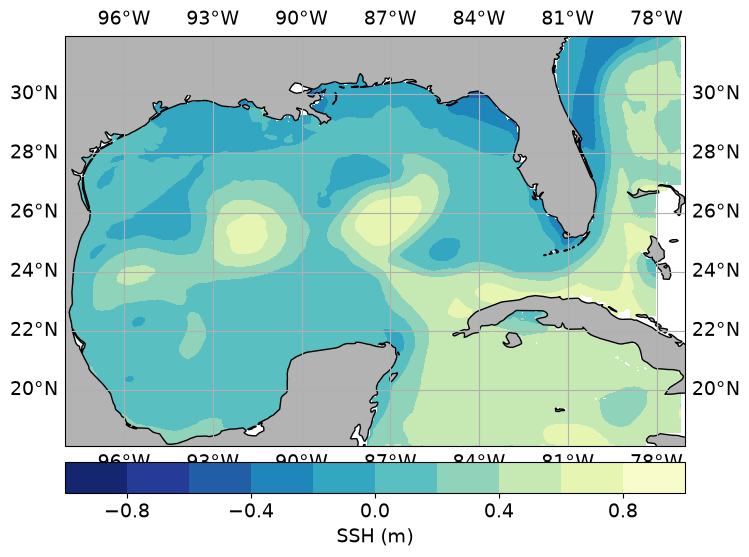

In [18]:
#exact same code as before
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1,1.1, 0.2) #start,stop,step  
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'YlGnBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)

cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)

#### Not bad

## Lab 6.2

**E.0** Finish Lab 6.1 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 3-4. Let me know if this feels like a good pace

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

Error bars summarize the distribution of the data in one number, such as the standard deviation of the values.

choosing a style
for example
plt.style.use("ggplot")
after choosing the style,  this style will apply to all of the figures in your current session until you change it 

to go back to the default style
plt.style.use(default)

colorblind frindly  "seaborn-colorblind"  "tableau-colorblind10".

 Use the "Solarize_Light2" style and create new Figure/Axes
plt.style.use('Solarize_Light2')
fig,ax=plt.subplots()
ax.plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"])
plt.show()

 Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv',parse_dates=['date'], index_col='date')

**E.3** Make a plot of a different variable for the HYCOM data. Play around with colormaps and contourlines to make it your own. Post your plot on the class slack #programming channel

In [12]:
print(gom_data.data_vars)

Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...


In [14]:
var = gom_data.mixed_layer_thickness[0,:,:]

In [17]:
print(var.min().item())

0.5431861877441406


In [19]:
print(var.max().item())

146.0650634765625


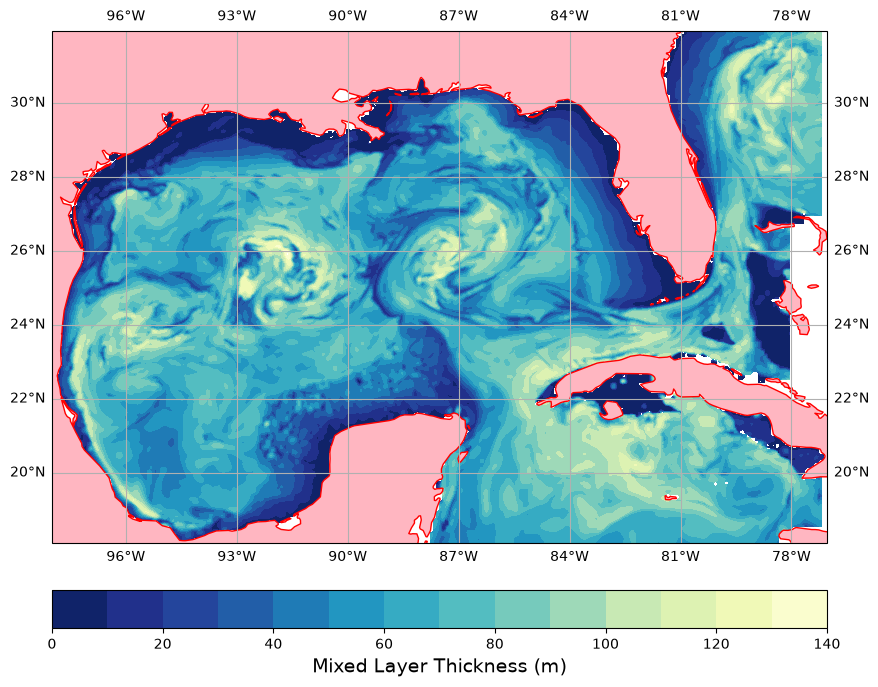

In [26]:

fig,ax= plt.subplots(figsize =(10,12),subplot_kw=dict(projection=ccrs.PlateCarree()))


land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='red',
                                    facecolor='lightpink')
ax.add_feature(land_50m)
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.mixed_layer_thickness[0,:,:]

# let's fill in the range here:
step = np.arange(0,148, 10) #start,stop,step  
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'YlGnBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal',pad=0.05)

cbar.set_label("Mixed Layer Thickness" +' (m)', size = 14)

ax.gridlines(draw_labels=True)

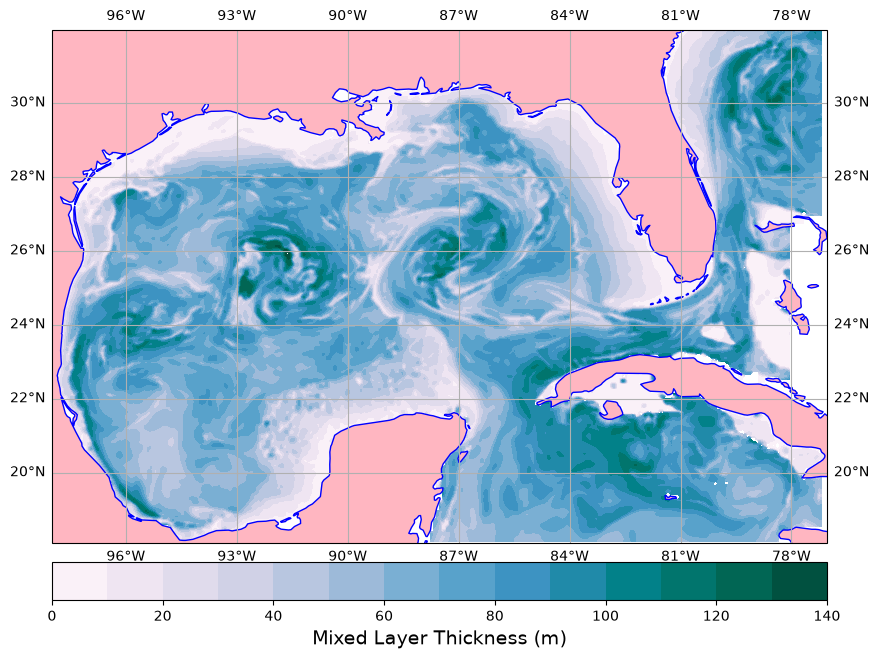

In [24]:
fig,ax= plt.subplots(figsize =(10,12),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='blue',
                                    facecolor='lightpink')
ax.add_feature(land_50m)
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.mixed_layer_thickness[0,:,:]

# let's fill in the range here:
step = np.arange(0,148, 10) #start,stop,step  
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'PuBuGn', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)

cbar.set_label("Mixed Layer Thickness" +' (m)', size = 14)

ax.gridlines(draw_labels=True)

### This week's project:

#### Note you might want to restart your kernel at this point to dump all the hycom data from memory. Just reload the packages you need

**E.4** Download some data from the ISIMIP data archive (https://data.isimip.org/) and plot it using cartopy. ISIMIP provides bias-corrected daata for past and future climate simulations used for impacts studies world wide. Let's start with some maximum atmospheric surface temperature data in the historical period (1850-2014 for CMIP6). We want climate forcing data for ISIMIP3b, which are the lastest (CMIP6) climate projections. 

* https://data.isimip.org/search/tree/ISIMIP3b/InputData/climate/
* Click atmopsheric forcing
* Click GFDL... This is one of NOAA-GFDL's climate models (ESM4)
* Click historical

All of the variable names are in CMIP lingo. Sadly, there is no easy cheat sheet. But you want tas, which is "temperature of air at surface". Let's use the tasmax, the maximum daily surface air temperature
* Click tasmax
* Click files to see all the available files.
  
Here you have a choice, you can download an etire file (note the size) or you can use the "configure download" button, which has subsetting by space or country, as well as time opitons. You can click on a file name to see more info.
* Click on "download file" for the 1851-1860 file. Just grab the whole file, it will take a minute to download.
* Load up the data into xarray and plot the maximum of this dataset (so max over the decade for each gridcell. You just use a max function for this, no loops needed).
* Plot using cartopy to make it pretty. Put some sensible lables on it, etc. Maybe add some country boundaries.

In [3]:
past= xr.open_dataset(
    "gfdl-esm4_r1i1p1f1_w5e5_historical_tasmax_global_daily_1851_1860.nc",
    decode_times=False
)

In [4]:
print(past.data_vars)

Data variables:
    tasmax   (time, lat, lon) float32 4GB ...


In [5]:
#to check the unit of temp
print(past['tasmax'].attrs)

{'standard_name': 'air_temperature', 'long_name': 'Daily Maximum Near-Surface Air Temperature', 'units': 'K'}


In [5]:
# to get the max
past_max= past['tasmax'].max(dim='time')

In [6]:
#changing k to C
past_max_c= past_max-273.15

In [9]:
#check the limit to set the range while plotting
max=past_max_c.max()
min=past_max_c.min()
print(max.item())
print(min.item())

52.400115966796875
-21.3834228515625


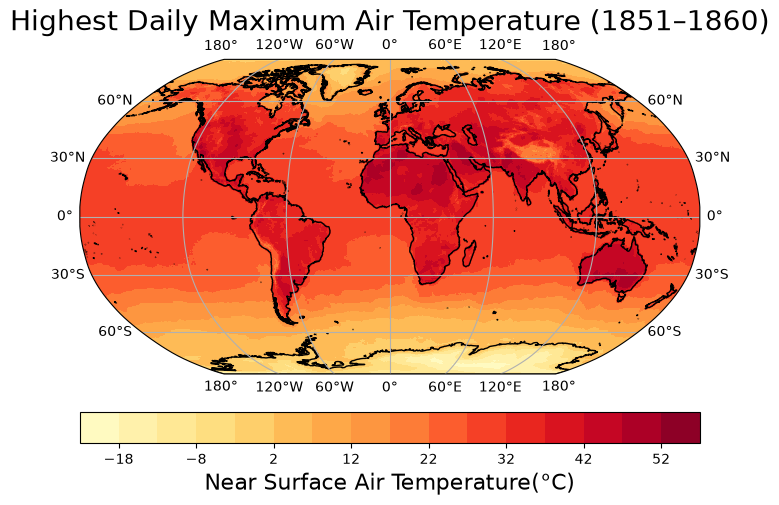

In [31]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.Robinson()))


# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='none')
ax.add_feature(land_50m)

# to keep the code clean:changing the name of variable and 
x = past_max_c["lon"]
y = past_max_c["lat"]
var = past_max_c
step = np.arange(-23, 60, 5)
# Contours the data on tho the map projection
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(),cmap='YlOrRd',levels=step) # projection is needed in every plot call


cbar = plt.colorbar(p, orientation='horizontal', pad=0.05)
cbar.set_label('Near Surface Air Temperature(°C)',
              size = 16)

ax.set_title("Highest Daily Maximum Air Temperature (1851–1860)",size=20)
ax.gridlines(draw_labels=True)

**E.5** Now make a second plot using ISIMP data for a future climate projection. Following the same steps as above, get the GFDL tasmax data for the future climate scenario SSP3-7.0 (higher emissions scenario) for 2051-2060. Again, calculate the maximum at each gridpoint for this data set. This is the future maximum daily temperature for that decade. Make your plot nice.

In [7]:
future= xr.open_dataset(
    "gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmax_global_daily_2051_2060.nc",
    decode_times=False
)

In [11]:
print(future.data_vars)

Data variables:
    tasmax   (time, lat, lon) float32 4GB ...


In [12]:
print(future["tasmax"].attrs)

{'standard_name': 'air_temperature', 'long_name': 'Daily Maximum Near-Surface Air Temperature', 'units': 'K'}


In [8]:
# to get the max
future_max= future['tasmax'].max(dim='time')

In [9]:
future_max_c= future_max-273.15

In [28]:
fmax=future_max_c.max()
fmin=future_max_c.min()
print(fmax.item())
print(fmin.item())

55.42626953125
-19.48101806640625


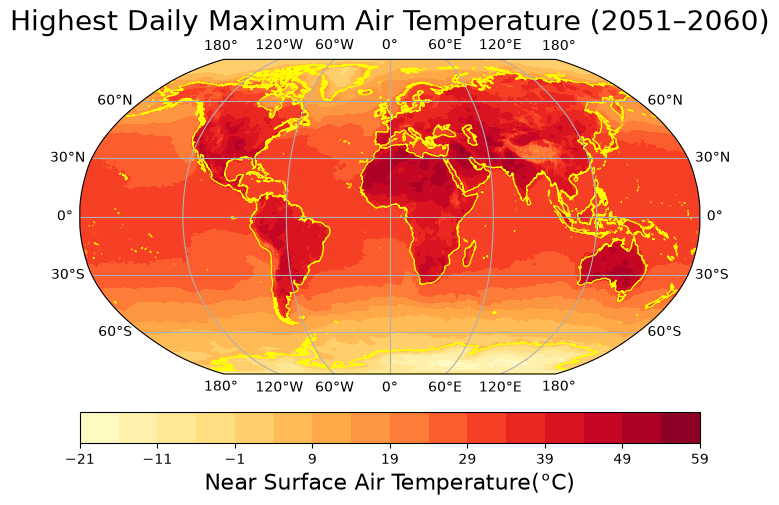

In [32]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.Robinson()))


# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='yellow',
                                    facecolor='none')
ax.add_feature(land_50m)

# to keep the code clean:changing the name of variable and 
x1 = future_max_c["lon"]
y1 = future_max_c["lat"]
var1 = future_max_c
step1 = np.arange(-21, 60, 5)
# Contours the data on tho the map projection
p = ax.contourf(x1, y1,var1, transform=ccrs.PlateCarree(),cmap='YlOrRd',levels=step1) # projection is needed in every plot call


cbar = plt.colorbar(p, orientation='horizontal', pad=0.05)
cbar.set_label('Near Surface Air Temperature(°C)',
              size = 16)

ax.set_title("Highest Daily Maximum Air Temperature (2051–2060)",size=20)
ax.gridlines(draw_labels=True)

**E.6** Now plot the anomaly between the two, 2050's - 1850's. Use a diverging colormap (light in the middle), centered on zero. What is the outlook for your country of orgin? Answer in full sentances with specific numbers.

In [10]:
anomaly=future_max_c - past_max_c

In [11]:
amax=anomaly.max()
amin=anomaly.min()
print(amax.item())
print(amin.item())

10.86083984375
-8.306732177734375


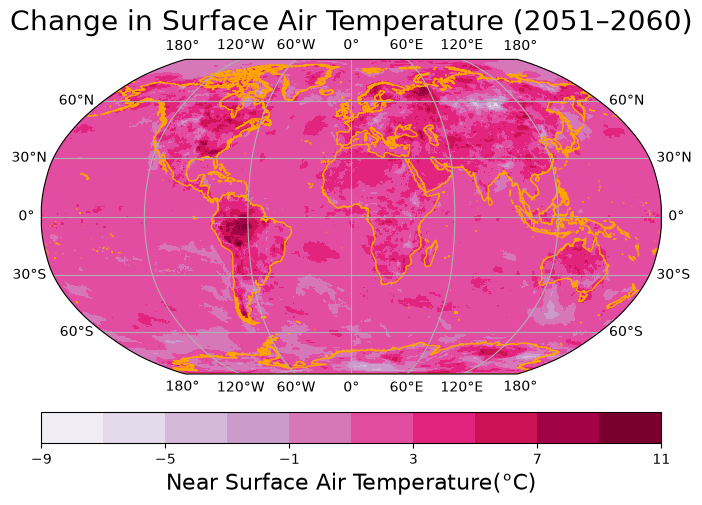

In [12]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.Robinson()))


# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='orange',
                                    facecolor='none')
ax.add_feature(land_50m)

# to keep the code clean:changing the name of variable and 
x2 = anomaly["lon"]
y2 = anomaly["lat"]
var2 = anomaly
step2 = np.arange(-9, 13, 2)
# Contours the data on tho the map projection
p = ax.contourf(x2, y2,var2, transform=ccrs.PlateCarree(),cmap='PuRd',levels=step2) # projection is needed in every plot call


cbar = plt.colorbar(p, orientation='horizontal', pad=0.05)
cbar.set_label('Near Surface Air Temperature(°C)',
              size = 16)

ax.set_title("Change in Surface Air Temperature (2051–2060)",size=20)
ax.gridlines(draw_labels=True)

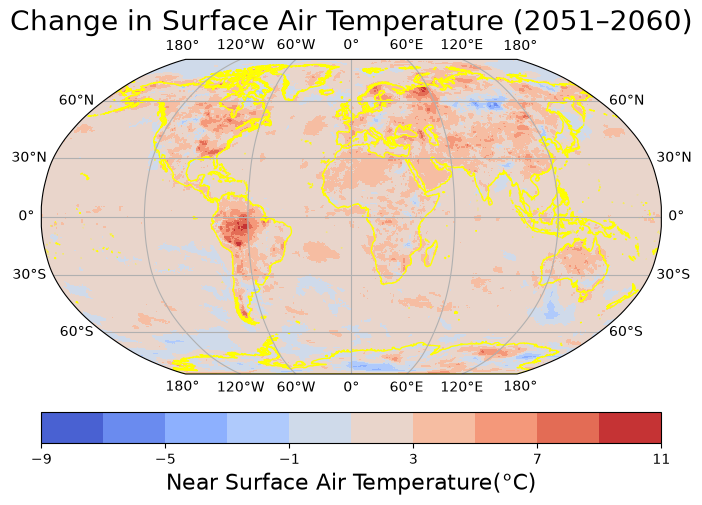

In [16]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.Robinson()))


# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='yellow',
                                    facecolor='none')
ax.add_feature(land_50m)

# to keep the code clean:changing the name of variable and 
x2 = anomaly["lon"]
y2 = anomaly["lat"]
var2 = anomaly
step2 = np.arange(-9, 13, 2)
# Contours the data on tho the map projection
p = ax.contourf(x2, y2,var2, transform=ccrs.PlateCarree(),cmap='coolwarm',levels=step2) # projection is needed in every plot call


cbar = plt.colorbar(p, orientation='horizontal', pad=0.05)
cbar.set_label('Near Surface Air Temperature(°C)',
              size = 16)

ax.set_title("Change in Surface Air Temperature (2051–2060)",size=20)
ax.gridlines(draw_labels=True)

C:\Users\Taherunnesa Rahi\anaconda3\Lib\site-packages\cartopy\io\__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


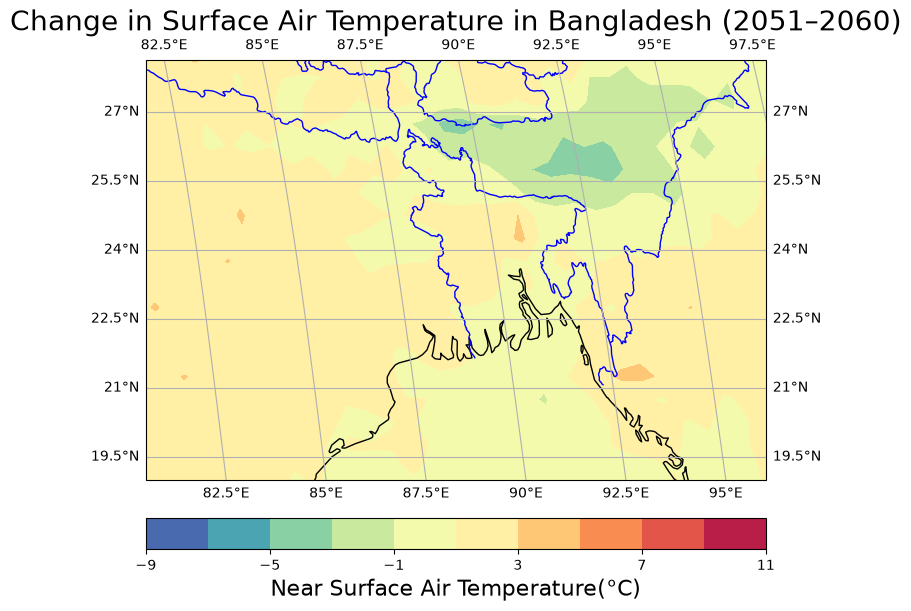

In [19]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.Robinson()))
ax.set_extent([82, 96, 19, 28])

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='none')
ax.add_feature(land_50m)
ax.add_feature(cfeature.BORDERS,edgecolor="blue")
# to keep the code clean:changing the name of variable and 
x2 = anomaly["lon"]
y2 = anomaly["lat"]
var2 = anomaly
step2 = np.arange(-9, 13, 2)
# Contours the data on tho the map projection
p = ax.contourf(x2, y2,var2, transform=ccrs.PlateCarree(),cmap='Spectral_r',levels=step2) # projection is needed in every plot call


cbar = plt.colorbar(p, orientation='horizontal', pad=0.05)
cbar.set_label('Near Surface Air Temperature(°C)',
              size = 16)

ax.set_title("Change in Surface Air Temperature in Bangladesh (2051–2060)",size=20)
ax.gridlines(draw_labels=True)

The map shows that temperature may increase between 1.5 and 3 degrees in Bangladesh. In one particular area towards the north of the capital, the increase may be higher than 3 degrees.

**E.7** How could you potentially use this kind of data (future climate projections) in your research? Do some brainstorming. Write down your thoughts here.

I could use this kind of data to investigate how climate change may impact lake ecology and water quality. I also can investigate how it may affect mosquito distribution and developement.